In [1]:
import pandas as pd
df = pd.read_csv("h2.csv")

In [2]:
df.shape

(79330, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79330 entries, 0 to 79329
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   79330 non-null  int64  
 1   LeadTime                     79330 non-null  int64  
 2   ArrivalDateYear              79330 non-null  int64  
 3   ArrivalDateMonth             79330 non-null  object 
 4   ArrivalDateWeekNumber        79330 non-null  int64  
 5   ArrivalDateDayOfMonth        79330 non-null  int64  
 6   StaysInWeekendNights         79330 non-null  int64  
 7   StaysInWeekNights            79330 non-null  int64  
 8   Adults                       79330 non-null  int64  
 9   Children                     79326 non-null  float64
 10  Babies                       79330 non-null  int64  
 11  Meal                         79330 non-null  object 
 12  Country                      79306 non-null  object 
 13  MarketSegment   

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

Children     4
Country     24
dtype: int64

In [5]:
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["Children"] = df["Children"].fillna(df["Children"].mean())

In [6]:
threshold = 0.0001 * len(df)  

agent_counts = df["Agent"].value_counts()
rare_agents = agent_counts[agent_counts < threshold].index
df["Agent"] = df["Agent"].replace(rare_agents, "Other")
print(rare_agents.shape)
 
country_counts = df["Country"].value_counts()
rare_agents = country_counts[country_counts < threshold].index
df["Country"] = df["Country"].replace(rare_agents, "Other")
print(rare_agents.shape)

Company_counts = df["Company"].value_counts()
rare_agents = Company_counts[Company_counts < threshold].index
df["Company"] = df["Company"].replace(rare_agents, "Other")
print(rare_agents.shape)

(83,)
(70,)
(143,)


In [7]:
df["DepositType"] = df["DepositType"].str.strip()

In [8]:
print(df["DepositType"].unique())
print(df["CustomerType"].unique())

['No Deposit' 'Non Refund' 'Refundable']
['Transient' 'Transient-Party' 'Contract' 'Group']


In [9]:
df.drop(["ReservationStatus", "ReservationStatusDate"], axis=1, inplace=True)

In [10]:
subset = df[
    (df["Adults"] == 0) &
    ((df["Children"] > 0) | (df["Babies"] > 0))
]

cancelled = (subset["IsCanceled"] == 1).sum()
total = len(subset)

print("Cancelled:", cancelled)
print("Total:", total)
print("Cancellation Percentage:", round(cancelled / total * 100, 2), "%")

Cancelled: 84
Total: 223
Cancellation Percentage: 37.67 %


In [11]:
df = df[~(
    (df["Adults"] == 0) &
    (df["Children"] == 0) &
    (df["Babies"] == 0)
)]

df = df[df["Adults"] > 0]

In [12]:
df.shape

(78940, 29)

In [13]:
df["TotalNights"] = (
    df["StaysInWeekendNights"] +
    df["StaysInWeekNights"]
)

df["TotalGuests"] = (
    df["Adults"] +
    df["Children"] +
    df["Babies"]
)

df["HasChildren"] = (df["Children"] + df["Babies"] > 0).astype(int)

df["LeadTimePerNight"] = df["LeadTime"] / (df["TotalNights"] + 1)

df["TotalPreviousBookings"] = (
    df["PreviousBookingsNotCanceled"] +
    df["PreviousCancellations"]
)

df["RoomChanged"] = (
    df["ReservedRoomType"] != df["AssignedRoomType"]
).astype(int)

df["ADRPerNight"] = df["ADR"] / (df["TotalNights"] + 1)

df["PreviousCancellationRate"] = (
    df["PreviousCancellations"] /
    (df["PreviousCancellations"] + df["PreviousBookingsNotCanceled"] + 1)
)

df["HadMeal"] = (~df["Meal"].isin(["SC", "Undefined"])).astype(int)



season_map = {
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn",
    "December": "Winter"
}
df["Season"] = df["ArrivalDateMonth"].map(season_map)

df["HasParking"] = (df["RequiredCarParkingSpaces"] > 0).astype(int)

# Lead Time
df["LeadTime_Bin"] = pd.cut(
    df["LeadTime"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]
)


# Total Nights
df["Nights_Bin"] = pd.cut(
    df["TotalNights"],
    bins=[0, 1, 3, 7, 14, float("inf")],
    labels=["1", "2-3", "4-7", "8-14", "15+"]
)

# Booking Changes
df["BookingChanges_Bin"] = pd.cut(
    df["BookingChanges"],
    bins=[-1, 0, 1, 3, float("inf")],
    labels=["0", "1", "2-3", "4+"]
)

# Special Requests
df["SpecialReq_Bin"] = pd.cut(
    df["TotalOfSpecialRequests"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["0", "1", "2", "3+"]
)

# Days in Waiting List
df["WaitingList_Bin"] = pd.cut(
    df["DaysInWaitingList"],
    bins=[-1, 0, 30, 90, float("inf")],
    labels=["0", "1-30", "31-90", "90+"]
)








In [14]:
df.shape

(78940, 45)

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children', 'Babies', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'BookingChanges', 'DaysInWaitingList', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'TotalNights', 'TotalGuests', 'HasChildren', 'LeadTimePerNight', 'TotalPreviousBookings', 'RoomChanged', 'ADRPerNight', 'PreviousCancellationRate', 'HadMeal', 'HasParking']
['ArrivalDateMonth', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'ReservedRoomType', 'AssignedRoomType', 'DepositType', 'Agent', 'Company', 'CustomerType', 'Season']


In [16]:
ohe_cols = [
    "ArrivalDateMonth",
    "Meal",
    "Country",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "AssignedRoomType",
    "Agent",
    "Company",
    "Season"
]
ordinal_cols = [
    "DepositType",
    "CustomerType"
]
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

In [17]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_df = pd.DataFrame(
    ohe.fit_transform(df[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index
)
df = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

In [18]:
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

ord_enc = OrdinalEncoder(categories=[deposit_order, customer_order])

df[["DepositType", "CustomerType"]] = ord_enc.fit_transform(
    df[["DepositType", "CustomerType"]]
)

In [19]:
df.shape

(78940, 387)

In [20]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop("IsCanceled", axis=1)
y = df["IsCanceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
from xgboost import plot_importance

In [39]:

# Model
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]


In [23]:
X.shape

(78940, 386)

In [24]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

low_features = importance[importance["Importance"] < 0.005]["Feature"]

X_new = X.drop(columns=low_features)

print(low_features)

50              Country_AGO
151    MarketSegment_Groups
272       Agent_        191
364     Company_        333
275       Agent_        195
               ...         
273       Agent_        192
274       Agent_        193
277       Agent_        205
278       Agent_        215
103             Country_KWT
Name: Feature, Length: 369, dtype: object


In [25]:
X.shape

(78940, 386)

Accuracy : 0.8922599442614644
Precision: 0.8818210165263486
Recall   : 0.8570995605394757
F1 Score : 0.8692845615922539
ROC-AUC  : 0.9610216238074701

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      9189
           1       0.88      0.86      0.87      6599

    accuracy                           0.89     15788
   macro avg       0.89      0.89      0.89     15788
weighted avg       0.89      0.89      0.89     15788


Confusion Matrix:

[[8431  758]
 [ 943 5656]]

CV Scores: [0.89409678 0.89263998 0.88953636 0.88947302 0.88985305]
Mean CV Accuracy: 0.8911198378515328


<Figure size 1000x800 with 0 Axes>

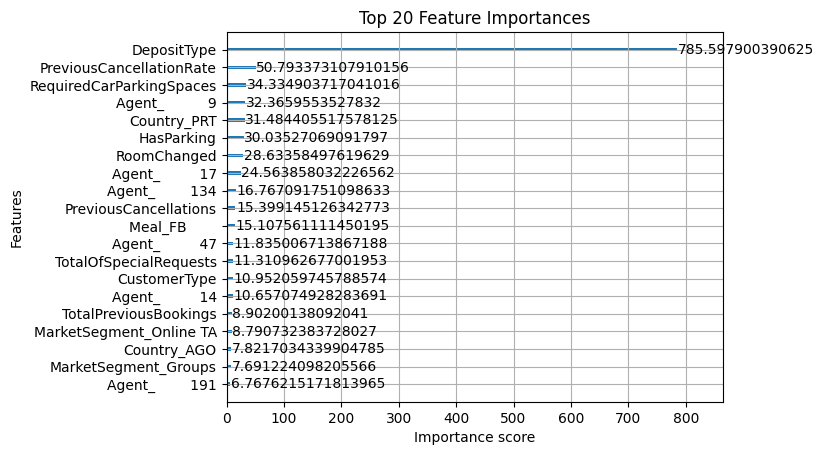

In [26]:
# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Feature Importance Plot
plt.figure(figsize=(10,8))
plot_importance(
    xgb,
    max_num_features=20,
    importance_type="gain"
)
plt.title("Top 20 Feature Importances")
plt.show()

In [27]:
best_score = 0
best_gamma = None

for gamma in [0, 0.1, 0.3, 0.5, 1]:
    model = XGBClassifier(
        n_estimators=700,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=gamma,
        random_state=42,
        eval_metric="logloss"
    )

    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="accuracy", n_jobs=-1)

    print(f"Gamma={gamma}, CV={scores.mean():.5f}")

    if scores.mean() > best_score:
        best_score = scores.mean()
        best_gamma = gamma

print(best_gamma, best_score)

best_score = 0
best_mcw = None

for mcw in [1, 3, 5, 7, 10]:
    model = XGBClassifier(
        n_estimators=700,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=best_gamma,
        min_child_weight=mcw,
        random_state=42,
        eval_metric="logloss"
    )

    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="accuracy", n_jobs=-1)

    print(f"MinChildWeight={mcw}, CV={scores.mean():.5f}")

    if scores.mean() > best_score:
        best_score = scores.mean()
        best_mcw = mcw

print(best_mcw, best_score)

best_score = 0
best_alpha = None

for alpha in [0, 0.01, 0.1, 0.5, 1]:
    model = XGBClassifier(
        n_estimators=700,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=best_gamma,
        min_child_weight=best_mcw,
        reg_alpha=alpha,
        random_state=42,
        eval_metric="logloss"
    )

    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="accuracy", n_jobs=-1)

    print(f"RegAlpha={alpha}, CV={scores.mean():.5f}")

    if scores.mean() > best_score:
        best_score = scores.mean()
        best_alpha = alpha

print(best_alpha, best_score)

best_score = 0
best_lambda = None

for lam in [0.5, 1, 2, 5, 10]:
    model = XGBClassifier(
        n_estimators=700,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=best_gamma,
        min_child_weight=best_mcw,
        reg_alpha=best_alpha,
        reg_lambda=lam,
        random_state=42,
        eval_metric="logloss"
    )

    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="accuracy", n_jobs=-1)

    print(f"RegLambda={lam}, CV={scores.mean():.5f}")

    if scores.mean() > best_score:
        best_score = scores.mean()
        best_lambda = lam

print(best_lambda, best_score)

Gamma=0, CV=0.88656
Gamma=0.1, CV=0.88661
Gamma=0.3, CV=0.88762
Gamma=0.5, CV=0.88672
Gamma=1, CV=0.88545
0.3 0.8876203509155953
MinChildWeight=1, CV=0.88762
MinChildWeight=3, CV=0.88494
MinChildWeight=5, CV=0.88360
MinChildWeight=7, CV=0.88301
MinChildWeight=10, CV=0.88295
1 0.8876203509155953
RegAlpha=0, CV=0.88762
RegAlpha=0.01, CV=0.88844
RegAlpha=0.1, CV=0.88711
RegAlpha=0.5, CV=0.88591
RegAlpha=1, CV=0.88613
0.01 0.88844374956787
RegLambda=0.5, CV=0.88751
RegLambda=1, CV=0.88844
RegLambda=2, CV=0.88656
RegLambda=5, CV=0.88648
RegLambda=10, CV=0.88499
1 0.88844374956787


In [34]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


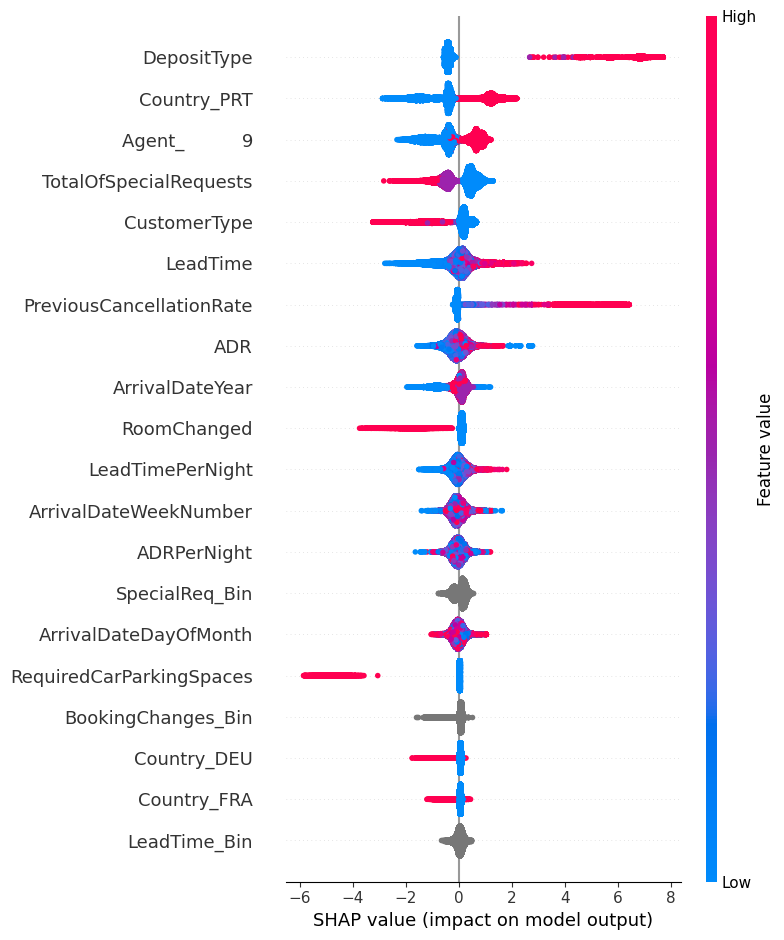

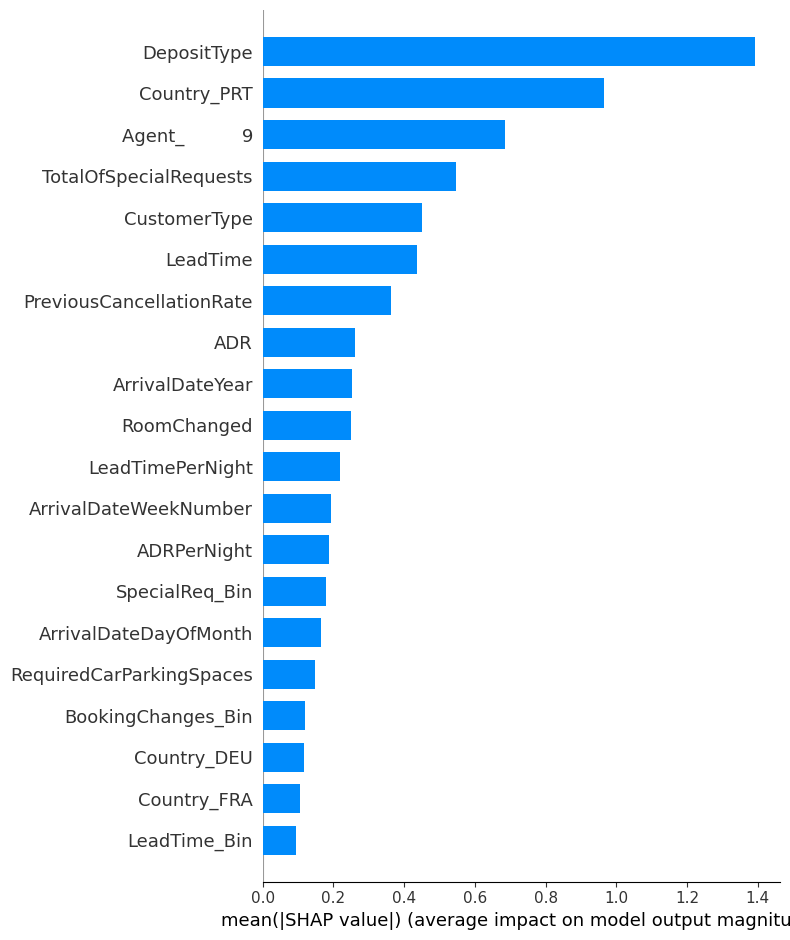

In [28]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)
shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar"
)

In [31]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="Importance", ascending=False)

print(importance)

                    Feature  Importance
13              DepositType    1.393008
126             Country_PRT    0.964756
183       Agent_          9    0.685060
18   TotalOfSpecialRequests    0.545610
15             CustomerType    0.450493
..                      ...         ...
273       Agent_        192    0.000000
270       Agent_        177    0.000000
269       Agent_        174    0.000000
131             Country_SEN    0.000000
232       Agent_         82    0.000000

[386 rows x 2 columns]


In [32]:
zero_imp = importance[importance["Importance"] == 0]

print(zero_imp)

                 Feature  Importance
340  Company_        148         0.0
339  Company_        144         0.0
317  Company_          9         0.0
338  Company_        143         0.0
337  Company_        127         0.0
..                   ...         ...
273    Agent_        192         0.0
270    Agent_        177         0.0
269    Agent_        174         0.0
131          Country_SEN         0.0
232    Agent_         82         0.0

[126 rows x 2 columns]


In [33]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [34]:
print(shap_values.shape)

(63152, 386)


In [35]:
print(shap_values.shape)

(63152, 386)


In [36]:
zero_features = importance.loc[
    importance["Importance"] == 0,
    "Feature"
].tolist()

print(len(zero_features))
print(zero_features)

126
['Company_        148', 'Company_        144', 'Company_          9', 'Company_        143', 'Company_        127', 'Company_        150', 'Company_         91', 'Company_        122', 'Company_        120', 'Company_        107', 'Company_        105', 'Company_         37', 'Company_         78', 'Country_KWT', 'Company_         43', 'Country_KAZ', 'Company_         72', 'Company_         46', 'Company_         62', 'Company_         47', 'Company_         81', 'Agent_         39', 'Country_CYP', 'Company_        366', 'HadMeal', 'Country_GEO', 'Company_        485', 'Company_        465', 'Company_        450', 'Company_        435', 'Company_        424', 'Company_        418', 'Company_        409', 'Company_        408', 'Company_        407', 'Company_        405', 'Company_        396', 'Company_        385', 'Company_        348', 'Company_        163', 'Country_GNB', 'Company_        242', 'Company_        227', 'Company_        218', 'Company_        215', 'Company_     

In [37]:
X_train = X_train.drop(columns=zero_features)
X_test = X_test.drop(columns=zero_features)

In [38]:
X_train.shape

(63152, 260)

Accuracy : 0.8916898910564987
Precision: 0.880111957704867
Recall   : 0.8577057129868162
F1 Score : 0.8687643898695319
ROC-AUC  : 0.9606900836833726

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      9189
           1       0.88      0.86      0.87      6599

    accuracy                           0.89     15788
   macro avg       0.89      0.89      0.89     15788
weighted avg       0.89      0.89      0.89     15788


Confusion Matrix:

[[8418  771]
 [ 939 5660]]

CV Scores: [0.89409678 0.89263998 0.88953636 0.88947302 0.88985305]
Mean CV Accuracy: 0.8911198378515328


<Figure size 1000x800 with 0 Axes>

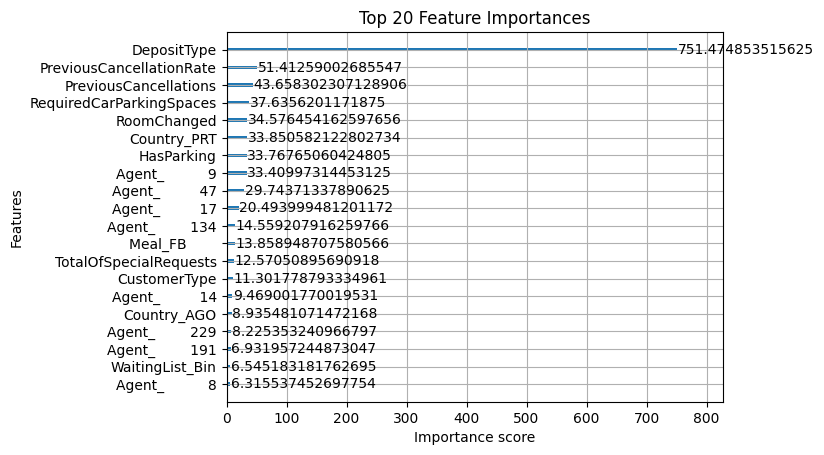

In [40]:
# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Feature Importance Plot
plt.figure(figsize=(10,8))
plot_importance(
    xgb,
    max_num_features=20,
    importance_type="gain"
)
plt.title("Top 20 Feature Importances")
plt.show()